ML for Robotics Lab - 9

Use Lab9_Go2_SensorData.csv, identify the feature that will separate the label. Apply SVM to classify the data

Feature that best separates the label: joint_value_FR_Thigh


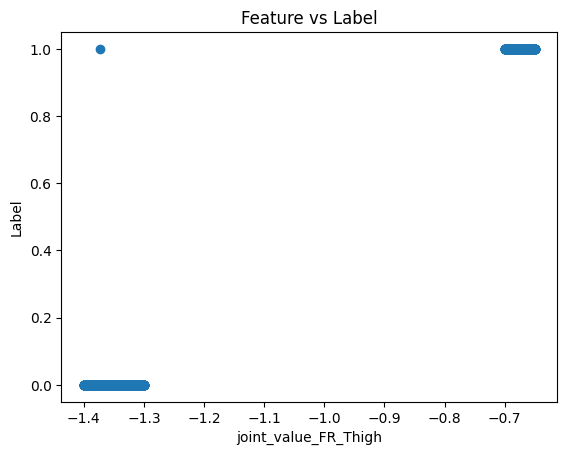


SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       295
           1       1.00      1.00      1.00       305

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Accuracy: 1.0


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
data = pd.read_csv("/content/Go2_SensorData.csv")
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
correlation = X.corrwith(y)
top_feature = correlation.abs().idxmax()
print("Feature that best separates the label:", top_feature)
plt.figure()
plt.scatter(X[top_feature], y)
plt.xlabel(top_feature)
plt.ylabel("Label")
plt.title("Feature vs Label")
plt.show()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

In [22]:
for feature in X.columns:
    X_single = X[[feature]]
    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.3, random_state=42
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = SVC(kernel='rbf')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{feature} --> Accuracy: {acc:.4f}")

joint_value_FR_Thigh --> Accuracy: 1.0000
accel_x --> Accuracy: 0.6750
accel_y --> Accuracy: 0.7150
accel_z --> Accuracy: 0.6100
foot_force --> Accuracy: 0.7950


Use MLP on the data in Lab9_1. MLP - Sit_StandClassify_img.zip and classify the data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lab9_1. MLP - Sit_StandClassify_img.zip to Lab9_1. MLP - Sit_StandClassify_img.zip


In [23]:
import zipfile
zip_path = "Lab9_1. MLP - Sit_StandClassify_img.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")
print("Dataset extracted")

Dataset extracted


In [24]:
import os
import cv2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
X = []
y = []
dataset_path = os.path.join("dataset", "1. MLP - Sit_StandClassify_img")
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not load image {img_path}. Skipping.")
                continue
            img = cv2.resize(img, (32,32))
            img = img.flatten()
            X.append(img)
            y.append(label)
X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
print("Dataset shape:", X.shape)
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
mlp = MLPClassifier(
    hidden_layer_sizes=(256,128),
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset shape: (33, 1024)
Accuracy: 1.0

Confusion Matrix:
 [[2 0]
 [0 5]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         5

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



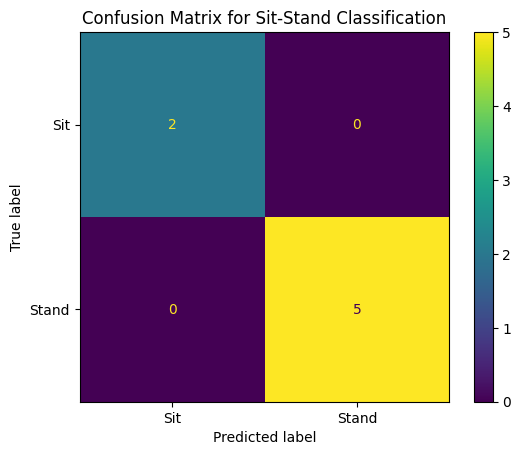

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Sit","Stand"])
disp.plot()
plt.title("Confusion Matrix for Sit-Stand Classification")
plt.show()

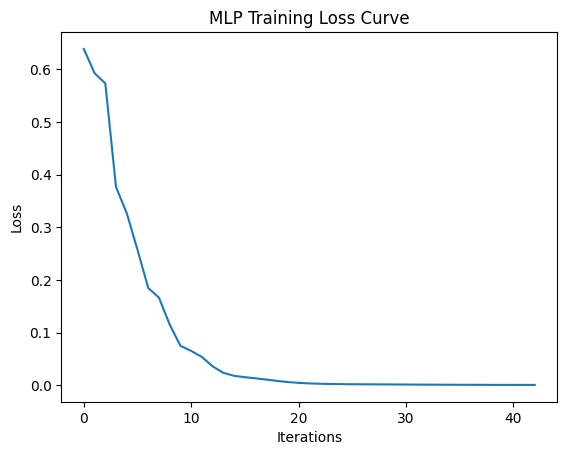

In [26]:
plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.show()

In [31]:
import zipfile
import io
import numpy as np
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
ImageFile.LOAD_TRUNCATED_IMAGES = True
zip_path = "Lab9_1. MLP - Sit_StandClassify_img.zip"
X = []
y = []
with zipfile.ZipFile(zip_path) as z:
    for name in z.namelist():
        if name.lower().endswith(".jpg") and "__macosx" not in name.lower():
            if "/sit/" in name.lower():
                label = 0
            else:
                label = 1

            img = Image.open(io.BytesIO(z.read(name)))
            img = img.convert("L").resize((64,64))

            arr = np.array(img).flatten() / 255.0

            X.append(arr)
            y.append(label)

X = np.array(X)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
from PIL import Image
import numpy as np
import zipfile
import io
zip_path = "Lab9_1. MLP - Sit_StandClassify_img.zip"
image = "1. MLP - Sit_StandClassify_img/Stand/20260221123346.jpg"
with zipfile.ZipFile(zip_path) as z:
    with z.open(image) as img_file:
        img = Image.open(img_file)
        img = img.convert("L").resize((64,64))
img_array = np.array(img).flatten() / 255.0
img_array = img_array.reshape(1, -1)
prediction = mlp.predict(img_array)
if prediction[0] == 0:
    print("Prediction: Sit")
else:
    print("Prediction: Stand")

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Prediction: Stand
